In [ ]:
%load_ext autoreload
%autoreload 2
import bqn
import numpy as np
# bqn.call("1+",np.arange(5))
# bqn.call("a←5×↕10", np.arange(10))
# bqn.eval("11+22")
# bqn.call("+`", np.arange(20))#.astype(int)
bqn.call("+´", np.arange(20))

In [ ]:
np.arange(40).sum()

In [ ]:
import numpy as np
import bqn
# bqn.eval("1‿2‿3")
bqn.check_array_type(np.array([1000.9]))
# bqn.eval("11+22")

In [ ]:
np.ones(1)*1.111111111111111111111

In [1]:
%load_ext autoreload
%autoreload 2
import warnings
warnings.filterwarnings('ignore')
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import pandas_ta as ta
import math
from tqdm import tqdm


from position_tools import calculate_trades, calculate_positions

In [2]:
import optuna
optuna.logging.set_verbosity(optuna.logging.ERROR)

# You can use Matplotlib instead of Plotly for visualization by simply replacing `optuna.visualization` with
# `optuna.visualization.matplotlib` in the following examples.
from optuna.visualization import plot_contour
from optuna.visualization import plot_edf
from optuna.visualization import plot_intermediate_values
from optuna.visualization import plot_optimization_history
from optuna.visualization import plot_parallel_coordinate
from optuna.visualization import plot_param_importances
from optuna.visualization import plot_rank
from optuna.visualization import plot_slice
from optuna.visualization import plot_timeline

In [3]:
def load_json_candles(fname):
    data = pd.read_json(fname)
    data.columns = ['timestamp', 'open', 'high', 'low', 'close', 'volume']
    data['timestamp'] = pd.to_datetime(data['timestamp'], unit='ms')
    data.set_index('timestamp', inplace=True)
    return data

def load_candles(exchange,base,quote,timeframe):
    fname = f'/media/mu6mula/Data/Crypto-Data-Feed/freq-user-data/data/{exchange}/{base}_{quote}-{timeframe}.json'
    return load_json_candles(fname)

def load_futures_candles(exchange,base,quote,timeframe):
    fname = f'/media/mu6mula/Data/Crypto-Data-Feed/freq-user-data/data/{exchange}/futures/{base}_{quote}_{quote}-{timeframe}-futures.json'
    return load_json_candles(fname)

def load_sp500_stock_candles(ticker):
    fname = f'/media/mu6mula/Data/Crypto-Data-Feed/sp500_data/{ticker}.csv'
    data = pd.read_csv(fname)
    data['Date'] = pd.to_datetime(data.Date)
    data.columns = [c.lower() for c in data.columns]
    data.set_index('date', inplace=True)
    return data

def load_russel2000_candles(ticker):
    fname = f'/media/mu6mula/Data/Crypto-Data-Feed/russell_2000_data/{ticker}.csv'
    data = pd.read_csv(fname)
    data['Date'] = pd.to_datetime(data.Date)
    data.columns = [c.lower() for c in data.columns]
    data.set_index('date', inplace=True)
    return data

In [4]:
print(np.get_include())
# gcc -shared -o positions.so -fPIC positions.c -I/home/mu6mula/miniconda3/envs/py310/include/python3.10 -I/home/mu6mula/miniconda3/envs/py310/include/python3.10 -I/home/mu6mula/miniconda3/envs/py310/lib/python3.10/site-packages/numpy/core/include

/home/mu6mula/miniconda3/envs/py310/lib/python3.10/site-packages/numpy/core/include


In [5]:


params = {'up_lookback': 39, 'dn_lookback': 30, 'up_lag': 3, 'dn_lag': 18}

data = load_candles('binance','BTC','USDT','1h')['2021-11':].iloc[:700]
data['lclose'] = data.close.apply(np.exp)
data['lret'] = data['lclose'].diff().fillna(0)

aparams = [{'up_lookback': 83, 'dn_lookback': 95, 'up_lag': 80, 'dn_lag': 94}, {'up_lookback': 94, 'dn_lookback': 74, 'up_lag': 53, 'dn_lag': 17}]
params = {'up_lookback': 83, 'dn_lookback': 95, 'up_lag': 80, 'dn_lag': 94}
Total Return: 80.61
Sharpe Ratio: 0.03
# Trades: 293
# Wins: 106
# Losses: 188
Win Ratio: 0.36
Profit Factor: 1.80
Win Ratio: 0.36
Average Win: 0.1527
Average Loss: -0.0479
Average DrawDown: -0.1810
Max Trade DrawDown: -0.5073


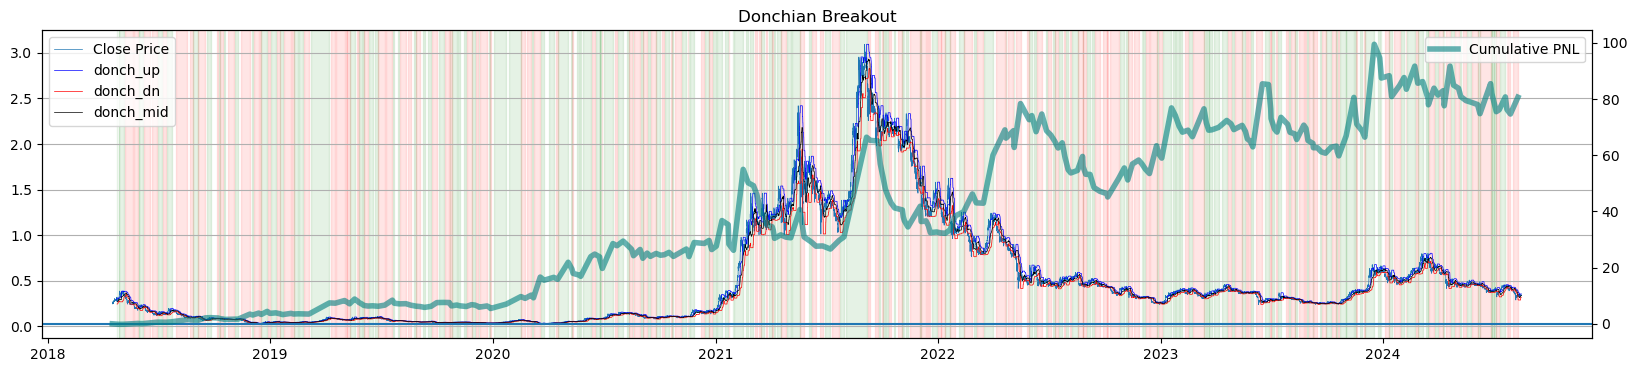

params = {'up_lookback': 94, 'dn_lookback': 74, 'up_lag': 53, 'dn_lag': 17}
Total Return: 113.75
Sharpe Ratio: 0.04
# Trades: 426
# Wins: 149
# Losses: 278
Win Ratio: 0.35
Profit Factor: 1.64
Win Ratio: 0.35
Average Win: 0.1303
Average Loss: -0.0425
Average DrawDown: -0.1744
Max Trade DrawDown: -0.4742


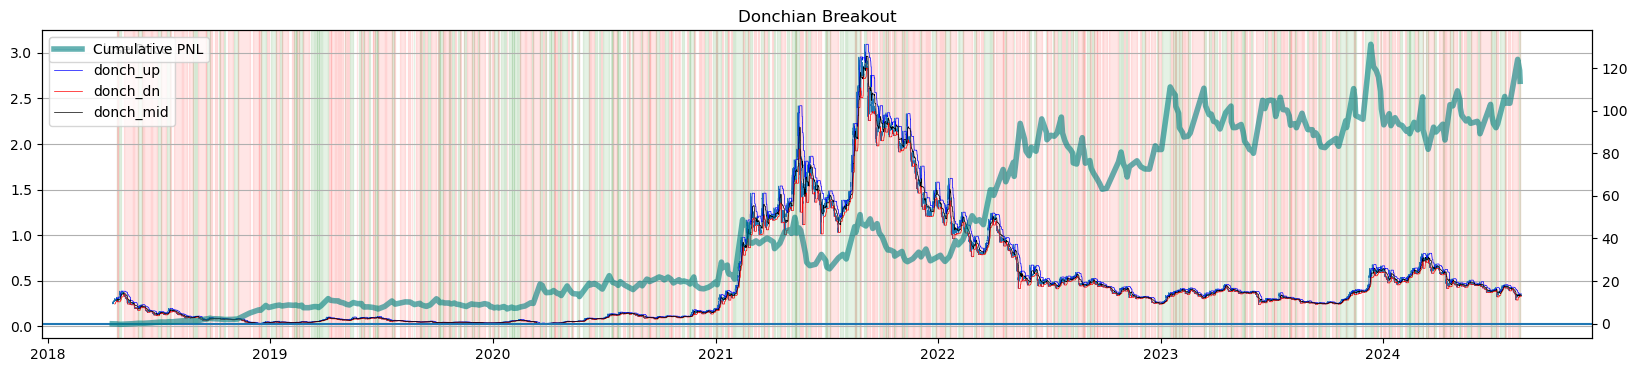

In [451]:

# Define transaction costs and slippage
transaction_cost = 0.001  # 0.1% transaction cost per trade
slippage = 0.003  # 0.1% slippage per trade

itrades
    
def backtest(data, params, nhours, short_long=None, xmult=1):
    if short_long is None: short_long = [1,-1]
    
    global itrades
    
    up_lookback = params['up_lookback']
    dn_lookback = params['dn_lookback']
    up_lag = params['up_lag']
    dn_lag = params['dn_lag']
    lclose = data['close'].apply(np.log)
    lrets = lclose.diff()

    data['donch_up'] = data['close'].rolling(window=up_lookback).max().shift(up_lag)
    data['donch_dn'] = data['close'].rolling(window=dn_lookback).min().shift(dn_lag)
    data['donch_mid'] = (data['donch_up'] + data['donch_dn']) / 2
    
    ind_undefs = data['donch_up'].isna() | data['donch_dn'].isna()
    
    bull = ( 
                    (~ind_undefs) &\
                    (data['close'] > data['donch_up']) #& \
                    # (data['donch_up'] > data['donch_dn'])
    ).astype(int)

    bull_end = ( 
                    (~ind_undefs) &\
                    (data['close'] < data['donch_mid']) #| \
                    # (data['donch_up'] < data['donch_dn'])
    ).astype(int)


    bear = ( 
                    (~ind_undefs) &\
                    (data['close'] < data['donch_dn']) #& \
                    # (data['donch_up'] < data['donch_dn'])
    ).astype(int)
    bear_end = ( 
                    (~ind_undefs) &\
                    (data['close'] > data['donch_mid']) #| \
                    # (data['donch_up'] > data['donch_dn'])
    ).astype(int)

    itrades = calculate_trades(int(1 in short_long)*bull.values, int(1 in short_long)*bull_end.values, int(-1 in short_long)*bear.values, int(-1 in short_long)*bear_end.values)
    ipositions = calculate_positions(itrades,len(lclose))

    entry_points = data.index[itrades[:,0]]
    exit_points = data.index[itrades[:,1]]
    trade_rets = pd.Series(np.append([0],itrades[:,2]*(lclose.values[itrades[:,1]] - lclose.values[itrades[:,0]])), index=data.index[np.append([0],itrades[:,1])])
    trade_rets -= (transaction_cost + slippage)
    trade_pnl = trade_rets.cumsum()
    strat_rets = lrets.shift() * ipositions
    strat_pnl = strat_rets.cumsum()
    
    n_trades = len(itrades)
    # strat_rets -= data['trade'].abs() * (transaction_cost + slippage)
    data['strat_pnl'] = strat_pnl
    
    ###
    strat_rets_pct = np.exp(strat_rets) - 1
    trade_rets_pct = np.exp(trade_rets) - 1
    strat_pnl_pct = np.exp(strat_pnl) - 1
    # trade_pnl_pct = np.exp(trade_pnl) - 1
    trade_pnl_pct = (trade_rets_pct + 1).cumprod() - 1
    # Calculate performance metrics
    tot_return = trade_pnl.iloc[-1]
    wins = trade_rets_pct[trade_rets_pct > 0];  
    losses = trade_rets_pct[trade_rets_pct < 0]
    nwins, nlosses = len(wins), len(losses)
    win_ratio = nwins/ (n_trades) if n_trades > 0 else np.nan
    profit_factor = wins.sum() / losses.abs().sum()
    strat_rets_mean = strat_rets_pct.mean()
    sharpe = strat_rets_mean / strat_rets_pct.std()
    sortino = strat_rets_mean / losses.std()
    avg_win = wins.mean() if len(wins) > 0 else np.nan
    avg_loss = losses.mean() if len(losses) > 0 else np.nan
    
    trade_running_max = trade_pnl.cummax()
    trade_drawdowns = (trade_pnl - trade_running_max)
    trade_max_drawdown = np.min(trade_drawdowns)
    trade_drawdowns_pct = np.exp(trade_drawdowns) - 1
    trade_max_drawdown_pct = np.min(trade_drawdowns_pct)
    
    return {'tot_return':tot_return, 
            'n_trades': n_trades, 
            'nwins':nwins, 'nlosses': nlosses, 'win_ratio': win_ratio, 'profit_factor': profit_factor, 
            'sharpe': sharpe, 'sortino': sortino, 
            'entry_points': entry_points, 'exit_points': exit_points, 
            'trade_rets': trade_rets, 'trade_pnl': trade_pnl, 'strat_rets': strat_rets, 'strat_pnl': strat_pnl, 
            'trade_rets_pct': trade_rets_pct, 'trade_pnl_pct': trade_pnl_pct, 'strat_rets_pct': strat_rets_pct, 'strat_pnl_pct': strat_pnl_pct, 
            'itrades': itrades,
            'avg_win': avg_win, 'avg_loss': avg_loss,
            'trade_max_drawdown': trade_max_drawdown, 'trade_drawdowns': trade_drawdowns,
            'trade_max_drawdown_pct': trade_max_drawdown_pct, 'trade_drawdowns_pct': trade_drawdowns_pct
            # 'trade_details': trade_details 
    }

 

def optimize(data, nhours, backtest_fn = backtest, short_long=None, xmult=1):
    # Define the objective function for Optuna
    def objective(trial):
        global data
        up_lookback = trial.suggest_int('up_lookback', 7, 100)
        dn_lookback = trial.suggest_int('dn_lookback', 7, 100)
        up_lag = trial.suggest_int('up_lag', 7, 100)
        dn_lag = trial.suggest_int('dn_lag', 7, 100)
        params = {
            'up_lookback': up_lookback,
            'dn_lookback': dn_lookback,
            'up_lag': up_lag,
            'dn_lag': dn_lag
        }
        res = backtest_fn(data,params,nhours,short_long, xmult=xmult)
        return res['trade_rets'].mean(), res['trade_drawdowns_pct'].mean()#/ math.cos(number_of_trades)

    # Run the optimization
    study = optuna.create_study(directions=['maximize','maximize'])
    study.optimize(objective, n_trials=100)

    # Get the best parameters
    return study
    

def print_performance(data, nhours, best_params, backtest_fn, short_long=None, xmult=1):
    # {'tot_return':tot_return, 'n_trades': n_trades, 'nwins':nwins, 'nlosses': nlosses, 'win_ratio': win_ratio, 'profit_factor': profit_factor, 'sharpe': sharpe, 'sortino': sortino, 'entry_points': entry_points, 'exit_points': exit_points, 'trade_rets': trade_rets, 'trade_pnl': trade_pnl}
    global res
    res = backtest_fn(data,params,nhours,short_long=short_long,xmult=xmult)
    print_res(res)
    # Plot the results with the best parameters
    # fig, (ax1, ax2) = plt.subplots(2, 1, figsize=(20, 7), sharex=True, height_ratios=[2, 1])
    fig, (ax1) = plt.subplots(figsize=(20, 4))

    ax1.plot(data.index, data['close'], label='Close Price', lw=0.5)
    ax1.plot(data.index, data['donch_up'], label='donch_up', color='blue', lw=0.5)
    ax1.plot(data.index, data['donch_dn'], label='donch_dn', color='red', lw=0.5)
    ax1.plot(data.index, data['donch_mid'], label='donch_mid', color='black', lw=0.5, linestyle='-')
    # ax1.scatter(res['entry_points'], data.loc[res['entry_points'], 'close'], marker='^', color='g', s=30, label='Entry', zorder=5, alpha=0.3)
    # ax1.scatter(res['exit_points'], data.loc[res['exit_points'], 'close'], marker='v', color='r', s=30, label='Exit', zorder=5, alpha=0.3)
    ax1.legend(loc='best')
    plt.title('Donchian Breakout')

    ax2 = ax1.twinx()
    ax2.axhline(0)
    # ax2.plot(res['strat_pnl_pct'], label='Unrealized PNL', color='blue', alpha=0.3)
    ax2.plot(res['trade_pnl_pct'], label='Cumulative PNL', color='teal', alpha=0.6, lw=4)
    # ax2.plot(data['cum_trd_rets'].apply(np.log)-1, label='Cumulative Returns', color='blue')
    
    ax2.legend(loc='best')
    
    # for x in res['entry_points'].values: 
    #     ax1.axvline(x,color='black', lw=1, alpha=0.1)
    #     # ax2.axvline(x,color='black', lw=1, alpha=0.1)
    # for xx in res['exit_points'].values:
    #     ax1.axvline(xx,color='red', lw=1, alpha=0.1)
    #     # ax2.axvline(xx,color='red', lw=1, alpha=0.1)
    for i in range(len(itrades)):
        ax1.axvspan(xmin=data.index[itrades[i,0]],xmax=data.index[itrades[i,1]], color=['red','green'][(itrades[i,2]+1)//2],alpha=0.1)
        # ax2.axvspan(xmin=data.index[itrades[i,0]],xmax=data.index[itrades[i,1]], color=['red','green'][(itrades[i,2]+1)//2],alpha=0.1)
    
    ax1.grid(axis='y')
    # ax2.grid(axis='y')
    plt.show()

def print_res(res):
    # Print performance metrics
    print(f"Total Return: {np.exp(res['tot_return'])-1:.2f}")
    print(f"Sharpe Ratio: {res['sharpe']:.2f}")
    print(f"# Trades: {res['n_trades']:.0f}")
    print(f"# Wins: {res['nwins']:.0f}")
    print(f"# Losses: {res['nlosses']:.0f}")
    print(f"Win Ratio: {res['win_ratio']:.2f}")
    print(f"Profit Factor: {res['profit_factor']:.2f}")
    print(f"Win Ratio: {res['win_ratio']:.2f}")
    # print(f"Annualized Return: {results['annualized_return']:.2f}")
    print(f"Average Win: {res['avg_win']:.4f}")
    print(f"Average Loss: {res['avg_loss']:.4f}")
    print(f"Average DrawDown: {res['trade_drawdowns_pct'].mean():.4f}")
    print(f"Max Trade DrawDown: {res['trade_max_drawdown_pct']:.4f}")
    
# Load the data
# ticker = 'GOOGL'
# data = load_sp500_stock_candles(ticker)['2020':'2025']
# data['close'] = data['adj close']
# data = load_russel2000_candles('XOXO')['2006':]
data = load_candles('binance','ADA','USDT','4h')#['2011':'2025']#.iloc[-10000:]
# # data = load_futures_candles('bybit','ALGO','USDT','1h')['2020-03':'2025']
# # data = data['2021-11-01':].copy()
nhours = 4
# data = data.resample(f'{nhours}H').agg( {'open': 'first','high': 'max','low': 'min','close': 'last','volume': 'sum'})
short_long = [-1,1]
def objective(trial):
    global data
    up_lookback = trial.suggest_int('up_lookback', 7, 100)
    dn_lookback = trial.suggest_int('dn_lookback', 7, 100)
    up_lag = trial.suggest_int('up_lag', 7, 100)
    dn_lag = trial.suggest_int('dn_lag', 7, 100)
    params = {
        'up_lookback': up_lookback,
        'dn_lookback': dn_lookback,
        'up_lag': up_lag,
        'dn_lag': dn_lag
    }
    res = backtest(data,params,nhours,short_long, xmult=1)
    return res['tot_return'], res['trade_max_drawdown']#/ math.cos(number_of_trades)

# Run the optimization
study = optuna.create_study(directions=['maximize','maximize'])
study.optimize(objective, n_trials=100)
study = optimize(data, nhours,backtest_fn=backtest, short_long=short_long)
aparams = [t.params for t in reversed(study.best_trials[-10:])]
# aparams = [{'up_lookback': 83, 'dn_lookback': 70, 'up_lag': 10, 'dn_lag': 47}, {'up_lookback': 84, 'dn_lookback': 47, 'up_lag': 55, 'dn_lag': 90}]

print(f'aparams = {aparams}')
for params in aparams:
    print(f'params = {params}')
    print_performance(data,nhours,params,backtest_fn=backtest,short_long=short_long, xmult=1)

In [ ]:
# plot_optimization_history(study, target='trade_rets')
plot_param_importances(study)

In [ ]:
optuna.visualization.plot_param_importances(
    study, target=lambda t: t.duration.total_seconds(), target_name="duration"
)

In [ ]:
optuna.visualization.plot_pareto_front(study, target_names=["tot_return", "trade_max_drawdown"])

In [ ]:
plot_edf(study,target=lambda s: s.values[0])

In [ ]:
plot_rank(study,target=lambda s: s.values[0])

In [ ]:
plot_timeline(study)

In [ ]:
fig = plot_intermediate_values(study)

# fig.update_layout(
#     title="Hyperparameter optimization for Donchian Breakout strategy",
#     xaxis_title="Epoch",
#     yaxis_title="tot_return",
# )
fig

In [ ]:
for params in [t.params for t in study.best_trials]:
    print(f'params = {params}')
    print_performance(data,nhours,params,backtest_fn=backtest,short_long=short_long, xmult=1)

## Optimize for all assets in a portfolio

In [346]:
import os
base_data_dir = "/media/mu6mula/Data/Crypto-Data-Feed/freq-user-data/data"
quote, timeframe = 'USDT', '8h'
exchanges = ['binance', 'kucoin', 'bybit', 'bitget']
assets = 'ADA','ALGO','ALU','AMP','APT','ARB','ATOM','AVAX','AXS','BEAM','BTC','CHZ','COQ','DOGE','DOT','EGLD','ENJ','ETH','GALA','GRT','ILV','IMX','INJ','KAS','KSM','LINK','LUNA','MANA','MATIC','MYRIA','NEAR','OP','PT','PYR','QNT','RAY','REN','RENDER','RUNE','SAND','SHIB','SNX','SOL','TET','TIA','XLM',
# df_pf = pd.DataFrame(assets,columns=['asset'])
df_pf = pd.DataFrame([
    [(os.path.exists(f'{base_data_dir}/{exchange}/{asset}_{quote}-{timeframe}.json')) for exchange in exchanges]
    for asset in assets
]).set_axis(exchanges, axis=1)
df_pf.index = assets

df_pf['first_exch'] = df_pf.apply(lambda row: row.idxmax() if row.any() else None, axis=1)
asset_exch = df_pf[~df_pf['first_exch'].isna()][['first_exch']].to_records()
# asset_files = [f'{base_data_dir}/{exchange}/{asset}_{quote}-{timeframe}.json' for (asset,exchange) in asset_exch]
asset_exch


rec.array([('ADA', 'binance'), ('ALGO', 'binance'), ('AMP', 'binance'),
           ('APT', 'binance'), ('ARB', 'binance'), ('ATOM', 'binance'),
           ('AVAX', 'binance'), ('AXS', 'binance'), ('BTC', 'binance'),
           ('CHZ', 'binance'), ('COQ', 'kucoin'), ('DOGE', 'binance'),
           ('DOT', 'binance'), ('EGLD', 'binance'), ('ENJ', 'binance'),
           ('ETH', 'binance'), ('GALA', 'binance'), ('GRT', 'binance'),
           ('ILV', 'binance'), ('IMX', 'binance'), ('INJ', 'binance'),
           ('KAS', 'kucoin'), ('KSM', 'binance'), ('LINK', 'binance'),
           ('LUNA', 'binance'), ('MANA', 'binance'), ('MATIC', 'binance'),
           ('MYRIA', 'kucoin'), ('NEAR', 'binance'), ('OP', 'binance'),
           ('PYR', 'binance'), ('QNT', 'binance'), ('RAY', 'binance'),
           ('REN', 'binance'), ('RUNE', 'binance'), ('SAND', 'binance'),
           ('SHIB', 'binance'), ('SNX', 'binance'), ('SOL', 'binance'),
           ('TIA', 'binance'), ('XLM', 'binance')],
          dt

In [385]:
short_long

[1]

In [419]:
short_long = [-1,1]
def objective(trial):
    global data
    up_lookback = trial.suggest_int('up_lookback', 7, 100)
    dn_lookback = trial.suggest_int('dn_lookback', 7, 100)
    up_lag = trial.suggest_int('up_lag', 7, 100)
    dn_lag = trial.suggest_int('dn_lag', 7, 100)
    params = {
        'up_lookback': up_lookback,
        'dn_lookback': dn_lookback,
        'up_lag': up_lag,
        'dn_lag': dn_lag
    }
    res = backtest(data,params,nhours,short_long, xmult=1)
    return res['tot_return'], res['trade_max_drawdown']#

def optimize_params(exchange, asset, timeframe):
    data = load_candles(exchange,asset,'USDT',timeframe)#['2011':'2025']#.iloc[-10000:]
    # Run the optimization
    study = optuna.create_study(directions=['maximize','maximize'])
    study.optimize(objective, n_trials=100)
    # asset_params[f'{asset}USDT'] = study.best_trials[-1].params
    # return [[t.params, t.values] for t in study.best_trials]
    return study.best_trials

sbest_trials = [optimize_params(exchange, asset, timeframe) for (asset,exchange) in asset_exch]
sbest_trials

[[FrozenTrial(number=38, state=TrialState.COMPLETE, values=[7.094003978599176, -0.49363201494738984], datetime_start=datetime.datetime(2024, 8, 15, 0, 36, 25, 398923), datetime_complete=datetime.datetime(2024, 8, 15, 0, 36, 25, 401432), params={'up_lookback': 47, 'dn_lookback': 10, 'up_lag': 57, 'dn_lag': 76}, user_attrs={}, system_attrs={'nsga2:generation': 0}, intermediate_values={}, distributions={'up_lookback': IntDistribution(high=100, log=False, low=7, step=1), 'dn_lookback': IntDistribution(high=100, log=False, low=7, step=1), 'up_lag': IntDistribution(high=100, log=False, low=7, step=1), 'dn_lag': IntDistribution(high=100, log=False, low=7, step=1)}, trial_id=38, value=None),
  FrozenTrial(number=80, state=TrialState.COMPLETE, values=[6.610903793972449, -0.42830869964859897], datetime_start=datetime.datetime(2024, 8, 15, 0, 36, 25, 519127), datetime_complete=datetime.datetime(2024, 8, 15, 0, 36, 25, 521771), params={'up_lookback': 47, 'dn_lookback': 10, 'up_lag': 51, 'dn_lag': 

In [424]:
import pickle
asset_trials = {asset_exch[i][0]: sbest_trials[i] for i in range(len(asset_exch))}
asset_trials
with open('portfolio-donchian-trials.pkl', 'wb') as f:
    pickle.dump(asset_trials, f)

In [ ]:
# Load the object from the file
with open('portfolio-donchian-trials.pkl', 'rb') as f:
    asset_trials = pickle.load(f)
asset_trials


In [438]:
best_params = [[[abt.params, abt.values] for abt in bt] for bt in sbest_trials]
best_params

[[[{'up_lookback': 47, 'dn_lookback': 10, 'up_lag': 57, 'dn_lag': 76},
   [7.094003978599176, -0.49363201494738984]],
  [{'up_lookback': 47, 'dn_lookback': 10, 'up_lag': 51, 'dn_lag': 83},
   [6.610903793972449, -0.42830869964859897]]],
 [[{'up_lookback': 92, 'dn_lookback': 77, 'up_lag': 8, 'dn_lag': 19},
   [5.322629296844289, -0.4639518479043141]],
  [{'up_lookback': 45, 'dn_lookback': 90, 'up_lag': 39, 'dn_lag': 54},
   [6.556304152944843, -0.4906276794119815]],
  [{'up_lookback': 45, 'dn_lookback': 90, 'up_lag': 51, 'dn_lag': 54},
   [6.658457267898388, -0.5766450066730525]],
  [{'up_lookback': 45, 'dn_lookback': 90, 'up_lag': 39, 'dn_lag': 54},
   [6.556304152944843, -0.4906276794119815]]],
 [[{'up_lookback': 79, 'dn_lookback': 11, 'up_lag': 22, 'dn_lag': 73},
   [6.792315278463991, -0.5305592262040273]],
  [{'up_lookback': 37, 'dn_lookback': 57, 'up_lag': 53, 'dn_lag': 72},
   [6.95562328330387, -0.5783565357858835]]],
 [[{'up_lookback': 35, 'dn_lookback': 9, 'up_lag': 75, 'dn_la

In [440]:
trial_n = 0
df_pf = pd.DataFrame([[f'{asset_exch[i][0]}USDT',best_trials[i][trial_n][0],best_trials[i][trial_n][1][0], best_trials[i][trial_n][1][1]] for i in range(len(asset_exch))]).set_axis(['asset','params','total_return','max_drawdown'],axis=1).set_index('asset')#[['val1','val2']]
df_pf.loc[:,['total_return','max_drawdown']] = df_pf.loc[:,['total_return','max_drawdown']].apply(np.exp).subtract(1)#.hist()
df_pf.sort_values('max_drawdown')

,params,total_return,max_drawdown
asset,,,
MATICUSDT,"{'up_lookback': 9, 'dn_lookback': 24, 'up_lag'...",945.775696,-0.599324
RENUSDT,"{'up_lookback': 50, 'dn_lookback': 12, 'up_lag...",1253.587258,-0.548199
MANAUSDT,"{'up_lookback': 62, 'dn_lookback': 59, 'up_lag...",721.296493,-0.526048
EGLDUSDT,"{'up_lookback': 65, 'dn_lookback': 8, 'up_lag'...",1450.884803,-0.490118
PYRUSDT,"{'up_lookback': 65, 'dn_lookback': 7, 'up_lag'...",1670.197451,-0.476321
MYRIAUSDT,"{'up_lookback': 29, 'dn_lookback': 16, 'up_lag...",1307.531784,-0.472089
GRTUSDT,"{'up_lookback': 55, 'dn_lookback': 27, 'up_lag...",1288.822103,-0.461644
COQUSDT,"{'up_lookback': 64, 'dn_lookback': 54, 'up_lag...",803.541438,-0.460876
AVAXUSDT,"{'up_lookback': 8, 'dn_lookback': 49, 'up_lag'...",829.257183,-0.459782


array([[<Axes: title={'center': 'up_lookback'}>,
        <Axes: title={'center': 'dn_lookback'}>],
       [<Axes: title={'center': 'up_lag'}>,
        <Axes: title={'center': 'dn_lag'}>]], dtype=object)

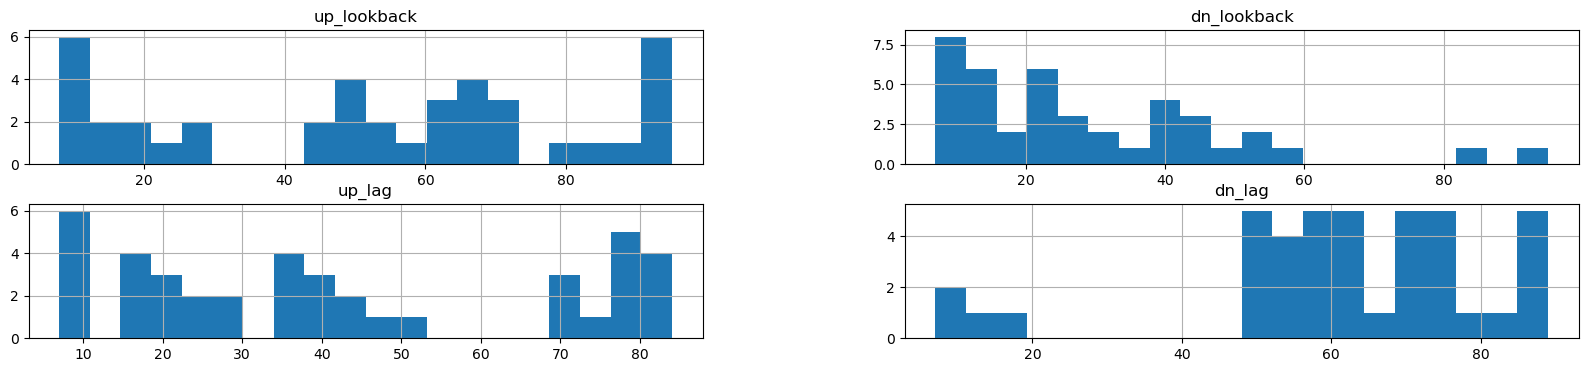

In [417]:
pd.DataFrame(df_pf.params.to_list()).hist(bins=20,figsize=(20,4))

In [410]:
asset_params = df_pf[['params']].to_dict()['params']
asset_params

{'MATICUSDT': {'up_lookback': 9,
  'dn_lookback': 24,
  'up_lag': 75,
  'dn_lag': 69},
 'RENUSDT': {'up_lookback': 50, 'dn_lookback': 12, 'up_lag': 42, 'dn_lag': 55},
 'MANAUSDT': {'up_lookback': 62,
  'dn_lookback': 59,
  'up_lag': 36,
  'dn_lag': 89},
 'EGLDUSDT': {'up_lookback': 65, 'dn_lookback': 8, 'up_lag': 20, 'dn_lag': 89},
 'PYRUSDT': {'up_lookback': 65, 'dn_lookback': 7, 'up_lag': 20, 'dn_lag': 89},
 'MYRIAUSDT': {'up_lookback': 29,
  'dn_lookback': 16,
  'up_lag': 77,
  'dn_lag': 62},
 'GRTUSDT': {'up_lookback': 55, 'dn_lookback': 27, 'up_lag': 30, 'dn_lag': 58},
 'COQUSDT': {'up_lookback': 64, 'dn_lookback': 54, 'up_lag': 23, 'dn_lag': 59},
 'AVAXUSDT': {'up_lookback': 8, 'dn_lookback': 49, 'up_lag': 81, 'dn_lag': 17},
 'SANDUSDT': {'up_lookback': 72, 'dn_lookback': 40, 'up_lag': 8, 'dn_lag': 55},
 'ENJUSDT': {'up_lookback': 11, 'dn_lookback': 44, 'up_lag': 84, 'dn_lag': 13},
 'ETHUSDT': {'up_lookback': 45, 'dn_lookback': 30, 'up_lag': 44, 'dn_lag': 62},
 'CHZUSDT': {'up_lo

## Generate pinescript for a bunch of assets

In [390]:
assets = ['ADA', 'ALGO', 'DOT', 'LINK', 'SOL']
exchange = 'BINANCE'
def objective(trial):
    global data
    up_lookback = trial.suggest_int('up_lookback', 7, 100)
    dn_lookback = trial.suggest_int('dn_lookback', 7, 100)
    up_lag = trial.suggest_int('up_lag', 7, 100)
    dn_lag = trial.suggest_int('dn_lag', 7, 100)
    params = {
        'up_lookback': up_lookback,
        'dn_lookback': dn_lookback,
        'up_lag': up_lag,
        'dn_lag': dn_lag
    }
    res = backtest(data,params,nhours,short_long, xmult=1)
    return res['tot_return'], res['trade_max_drawdown']#/ math.cos(number_of_trades)
nhours = 1
# data = data.resample(f'{nhours}H').agg( {'open': 'first','high': 'max','low': 'min','close': 'last','volume': 'sum'})
short_long = [1]
asset_params = {}
for asset in assets:
    data = load_candles('binance',asset,'USDT','8h')#['2011':'2025']#.iloc[-10000:]
    # Run the optimization
    study = optuna.create_study(directions=['maximize','maximize'])
    study.optimize(objective, n_trials=100)
    asset_params[f'{asset}USDT'] = study.best_trials[-1].params

In [369]:
asset_params

{'ADAUSDT': {'up_lookback': 80, 'dn_lookback': 38, 'up_lag': 86, 'dn_lag': 10},
 'ALGOUSDT': {'up_lookback': 89,
  'dn_lookback': 20,
  'up_lag': 81,
  'dn_lag': 20},
 'DOTUSDT': {'up_lookback': 47, 'dn_lookback': 24, 'up_lag': 30, 'dn_lag': 88},
 'LINKUSDT': {'up_lookback': 24, 'dn_lookback': 18, 'up_lag': 20, 'dn_lag': 7},
 'SOLUSDT': {'up_lookback': 61, 'dn_lookback': 82, 'up_lag': 24, 'dn_lag': 62}}

In [411]:
from jinja2 import Template

# Define the template (could also be loaded from a .jinja2 file)
template_str = """
//@version=5
indicator("Custom Donchian with Asset-Specific Parameters", overlay=true)

up_lag = 20
up_lookback = 20
dn_lag = 20
dn_lookback = 20
split_string = str.split(ticker.standard(),":")
string tkr = split_string.last()
// Determine parameters based on asset
{% for asset, params in asset_params.items() %}
if (tkr == "{{ asset }}")
    up_lag := {{ params.up_lag }}
    dn_lag := {{ params.dn_lag }}
    up_lookback := {{ params.up_lookback }}
    dn_lookback := {{ params.dn_lookback }}
{% endfor %}

// Upper Donchian Band: Highest high over the up_lookback period, shifted by donch_up periods
upper_band = ta.highest(high, up_lookback)[up_lag]
// Lower Donchian Band: Lowest low over the dn_lookback period, shifted by donch_dn periods
lower_band = ta.lowest(low, dn_lookback)[dn_lag]
// Middle line between the upper and lower bands
middle_line = (upper_band + lower_band) / 2

// Plotting the upper and lower bands
plot(upper_band, title="Upper Donchian Band", color=color.green, linewidth=2)
plot(lower_band, title="Lower Donchian Band", color=color.red, linewidth=2)
plot(middle_line, title="Middle Line", color=color.gray, linewidth=2)

"""

template_str2 = """
bla
{% for asset in assets %}
 "{{ asset }}"
{% endfor %}
"""
# Create a template object
template = Template(template_str)

# Render the template with the asset_params dictionary
rendered_pine_script = template.render(asset_params=asset_params)

# Output the generated Pine Script
print(rendered_pine_script)




//@version=5
indicator("Custom Donchian with Asset-Specific Parameters", overlay=true)

up_lag = 20
up_lookback = 20
dn_lag = 20
dn_lookback = 20
split_string = str.split(ticker.standard(),":")
string tkr = split_string.last()
// Determine parameters based on asset

if (tkr == "MATICUSDT")
    up_lag := 75
    dn_lag := 69
    up_lookback := 9
    dn_lookback := 24

if (tkr == "RENUSDT")
    up_lag := 42
    dn_lag := 55
    up_lookback := 50
    dn_lookback := 12

if (tkr == "MANAUSDT")
    up_lag := 36
    dn_lag := 89
    up_lookback := 62
    dn_lookback := 59

if (tkr == "EGLDUSDT")
    up_lag := 20
    dn_lag := 89
    up_lookback := 65
    dn_lookback := 8

if (tkr == "PYRUSDT")
    up_lag := 20
    dn_lag := 89
    up_lookback := 65
    dn_lookback := 7

if (tkr == "MYRIAUSDT")
    up_lag := 77
    dn_lag := 62
    up_lookback := 29
    dn_lookback := 16

if (tkr == "GRTUSDT")
    up_lag := 30
    dn_lag := 58
    up_lookback := 55
    dn_lookback := 27

if (tkr == "COQUSDT")


## Split data into training and testing set

In [ ]:
np.min([params[k] for k in params])

In [ ]:

data = load_candles('binance','BTC','USDT','1h')#.iloc[-5000:]
# data = load_futures_candles('bybit','ALGO','USDT','1h')['2020-03':'2025']
# data = data['2021-11-01':].copy()
nhours = 8
data = data.resample(f'{nhours}H').agg( {'open': 'first','high': 'max','low': 'min','close': 'last','volume': 'sum'})
short_long = [-1,1]

train_ratio = 0.3; 
cutoff = int(train_ratio * data.shape[0])
train_data, test_data = data.iloc[:cutoff,:], data.iloc[cutoff+1-np.max([params[k] for k in params]):,:]

study = optimize(train_data, nhours,backtest_fn=backtest, short_long=short_long)
params = study.best_params
params = {'tenkan_period': 19, 'kijun_period': 22, 'senkou_span_b_period': 22}
print(f'params = {params}')
print_performance(test_data,nhours,params,backtest_fn=backtest,short_long=short_long, xmult=1)
print_performance(train_data,nhours,params,backtest_fn=backtest,short_long=short_long, xmult=1)
print(f'params = {params}')

In [ ]:
train_data

## VectorBT Backtesting

In [ ]:
# import vectorbt as vbt

In [ ]:
import vectorbt as vbt
# import kaleido
vbt.settings.portfolio['init_cash'] = 100.  # 100$
vbt.settings.portfolio['fees'] = 0.002# 0.25%
vbt.settings.portfolio['slippage'] = 0.0025  # 0.25%

data = load_candles('binance','ADA','USDT','8h')
# nhours = 18
# data = data.resample(f'{nhours}H').agg({'open': 'first','high': 'max','low': 'min','close': 'last','volume': 'sum'})
params = {'tenkan_period': 15, 'kijun_period': 47, 'senkou_span_b_period': 30}
indicators(data, params)


buys = data['bull']
sells = data['bull_exit'] 

# buys = (data['bull'] & ~data['bull'].shift(fill_value=0)) 
# sells = data['bull_exit']  &~data['bull_exit'].shift(fill_value=0) 
portfolio = vbt.Portfolio.from_signals(data['close'], buys, sells, init_cash=100)
portfolio.stats()



## Backtrader

In [ ]:

import backtrader as bt
import backtrader.analyzers as btanalyzers
import backtrader.feeds as btfeeds
import backtrader.strategies as btstrats

In [ ]:

data = load_candles('binance','ALGO','USDT','1h')
ohlc_dict = {'open': 'first','high': 'max','low': 'min','close': 'last','volume': 'sum'}
nhours = 18
data = data.resample(f'{nhours}H').agg(ohlc_dict)
params = {'tenkan_period': 43, 'kijun_period': 34, 'senkou_span_b_period': 33}
indicators(data,params)
data['signal'] = (data['bull'] &~data['bull'].shift(fill_value=False)).astype(int) - (data['bull_exit'] &~data['bull_exit'].shift(fill_value=False)).astype(int) #- data['bear'].astype(int) + data['bear_exit'].astype(int)

init_cash = 100
fees = 0.075 # in %
list(enumerate(data.columns))

In [ ]:
data.bull

In [ ]:
import matplotlib.pyplot as plt
from pprint import pprint
%matplotlib inline

class PandasData(bt.feeds.PandasData):
    # Add a 'signal' line to the inherited lines from the base class 'PandasData'
    lines = ('signal',)

    # Define parameters for the added line
    params = (('signal', 14),)  # Default index 7 for 'Signal' column in the DataFrame

# Create a data feed from your Pandas DataFrame
data_feed = PandasData(dataname=data)

class MyStrategy(bt.Strategy):
    def __init__(self):
        self.signal = self.data.signal

    def next(self):
        if self.signal[0] == 1:
            if not self.position:  # Not in the market
                self.buy()
        elif self.signal[0] == 0:
            if self.position:  # In the market
                self.close()

# Instantiate Cerebro engine
cerebro = bt.Cerebro()

# Add your strategy
cerebro.addstrategy(MyStrategy)
cerebro.addanalyzer(btanalyzers.SharpeRatio, _name='mysharpe')
cerebro.addanalyzer(btanalyzers.Returns, _name='myreturns')
cerebro.addanalyzer(btanalyzers.TradeAnalyzer, _name='mytradeanlzr')

# Add the data feed to Cerebro
cerebro.adddata(data_feed)

# Set initial cash
cerebro.broker.setcash(100)


thestrats = cerebro.run()
thestrat = thestrats[0]

print('Sharpe Ratio:', thestrat.analyzers.mysharpe.get_analysis())
print('Returns:', thestrat.analyzers.myreturns.get_analysis())
# pprint((thestrat.analyzers.mytradeanlzr.get_analysis()))

# Get the figure object from cerebro.plot()
fig = cerebro.plot(iplot=False)[0][0]

# Display the plot using matplotlib
plt.show()

pprint(thestrat.analyzers.mytradeanlzr.get_analysis())

In [ ]:
list(thestrat.analyzers)

In [ ]:
class FullMoney(bt.sizers.PercentSizer):
    params = (
        ('percents', 100 - fees),
    )

class MySignal(bt.Indicator):
    lines = ('signal',)
    # params = (('period', 30),)

    def __init__(self):
        # self.lines.signal = self.data.bull - self.data.bear
        # self.lines.signal = data.bull.astype(int) - data.bear.astype(int)
        
data_bt = bt.feeds.PandasData(
    dataname=data,
    openinterest=-1,
    datetime=None,
    timeframe=bt.TimeFrame.Minutes,
    compression=1
 )

cerebro = bt.Cerebro(quicknotify=True)
cerebro.adddata(data_bt)
broker = cerebro.getbroker()
broker.set_coc(True) # cheat-on-close
broker.setcommission(commission=fees/100)#, name=coin_target)
broker.setcash(init_cash)
cerebro.addsizer(FullMoney)
cerebro.addanalyzer(bt.analyzers.TradeAnalyzer, _name="ta")
cerebro.addanalyzer(bt.analyzers.SQN, _name="sqn")
cerebro.addanalyzer(bt.analyzers.Transactions, _name="transactions")

# cerebro.adddata(data)

cerebro.add_signal(bt.SIGNAL_LONGSHORT, MySignal)
cerebro.run()

In [ ]:
class StrategyBase(bt.Strategy):
    def __init__(self):
        self.order = None
        self.last_operation = "SELL"
        self.status = "DISCONNECTED"
        self.buy_price_close = None
        self.pending_order = False
        self.commissions = []

    def notify_data(self, data, status, *args, **kwargs):
        self.status = data._getstatusname(status)

    def short(self):
        self.sell()

    def long(self):
        self.buy_price_close = self.data0.close[0]
        self.buy()

    def notify_order(self, order):
        self.pending_order = False
        if order.status in [order.Submitted, order.Accepted]:
            self.order = order
            return

        elif order.status in [order.Completed]:
            self.commissions.append(order.executed.comm)
            
            if order.isbuy():
                self.last_operation = "BUY"

            else:  # Sell
                self.buy_price_close = None
                self.last_operation = "SELL"

        self.order = None
        

# params= {'tenkan_period': 44, 'kijun_period': 32, 'senkou_span_b_period': 52}
class BasicIchimoku(StrategyBase):
    params = dict(
        tenkan_period=params['tenkan_period'],
        kijun_period=params['kijun_period'],
        senkou_span_b_period=params['senkou_span_b_period']
    )

    def __init__(self):
        StrategyBase.__init__(self)

        self.tenkan_sen = bt.indicators.EMA(period=self.p.tenkan_period)
        data['kijun_sen'] = bt.indicators.EMA(self.p.kijun_period)
        data['senkou_span_a'] = ((data['tenkan_sen'] + data['kijun_sen']) / 2).shift(self.p.kijun_period)
        data['senkou_span_b'] = bt.indicators.EMA(period=self.p.senkou_span_b_period).shift(self.p.kijun_period)

        self.profit = 0
        self.stop_loss_flag = True

    def update_indicators(self):
        self.profit = 0
        if self.buy_price_close and self.buy_price_close > 0:
            self.profit = float(
                self.data0.close[0] - self.buy_price_close) / self.buy_price_close

    def next(self):
        self.update_indicators()

        if self.order:  # waiting for pending order
            return

        # stop Loss
        ''' if self.profit < -0.03:
            self.short() '''

        # take Profit
        ''' if self.profit > 0.03:
            self.short() '''

        # reset stop loss flag
        # if self.rsi > self.p.rsi_bottom_threshold:
        #     self.stop_loss_flag = False

        if self.last_operation != "BUY":
            if ( (data['close'] > self.senkou_span_a) & \
            (data['close'] > data['senkou_span_b']) & \
            (data['tenkan_sen'] > data['kijun_sen']) & \
            (data['close'] > data['kijun_sen'])
    )
                  
    data['bull_exit'] = ((data['close'] < data['senkou_span_a']) | \
                        (data['close'] < data['senkou_span_b']))
             
            # if self.rsi < 30 and self.ema_fast > self.ema_slow:
            # if self.rsi < self.p.rsi_bottom_threshold:  # and not self.stop_loss_flag:
            #     self.long()

        if self.last_operation != "SELL":
            if self.rsi > self.p.rsi_top_threshold:
                self.short()

## Backtest in a LOOP

In [ ]:
   
def backtest(data, nhours, short_long=None, xmult=1):
    if short_long is None: short_long = [1,-1]

    # Initialize the 'position' column
    data['position'] = 0
    
    # # Set the 'position' column based on the signals
    if 1 in short_long:
        data.loc[data['bull'], 'position'] = 1        
        data.loc[(data['bull'] & data['bull_exit']), 'position'] = 0   
    # Exit position when exit signal is True
    
    # Set the 'position' column based on the signals
    if -1 in short_long:
        data.loc[(data['bear']), 'position'] = -1    
        data.loc[(data['bear'] & data['bear_exit']), 'position'] = 0
    ###    
    # data['position'] = xmult*(int(1 in short_long) * (data['bull'] &~ data['bull_exit'])) - (int(-1 in short_long) * (data['bear'] &~ data['bear_exit']))
    positions_shifted = data['position'].shift()#.fillna(0).astype(int)
    data['trade'] = data['position'].diff()#.fillna(0).astype(int)
    data.at[data.index[-1],'trade'] = -data.iloc[-1]['position']
    data['strategy_returns'] = positions_shifted * (data['lclose'].diff().fillna(0))
    number_of_trades = data['trade'].abs().sum()
    data['strategy_returns'] -= data['trade'].abs() * (transaction_cost + slippage)
    data['cumulative_returns'] = data['strategy_returns'].cumsum()
    
    data['pct_strategy_returns'] = np.exp(data['strategy_returns']) -1
    data['pct_cumulative_returns'] = np.exp(data['cumulative_returns']) -1
    ###
    
    
    # Apply transaction costs and slippage only on trades
    # data['strategy_returns'] -= data['trade'] * (transaction_cost + slippage)

    
    # Calculate performance metrics
    total_return = data['pct_cumulative_returns'].iloc[-1]
    annualized_return = data['pct_strategy_returns'].mean() * 365 * 24 / 8  # Assuming 8-hour bars
    annualized_volatility = data['pct_strategy_returns'].std() * np.sqrt(365 * 24 / nhours)
    sharpe_ratio = annualized_return / annualized_volatility
    

## Forward Testing

In [ ]:
# data = load_futures_candles('bybit','ADA','USDT','1h')['2020':'2023']
data = load_candles('binance','BTC','USDT','1h')['2020':'2025']
ohlc_dict = {'open': 'first','high': 'max','low': 'min','close': 'last','volume': 'sum'}
nhours = 8 ; ntrain = 3 ; ndays = 30
short_long = [1]
data = data.resample(f'{nhours}H').agg(ohlc_dict)#[:'2022']
n = data.shape[0]
w = (24 // nhours) * ndays
fwd_params = []
for i in tqdm(range(ntrain, (n // w)-1)):
    fwd_params.append(optimize(data.iloc[(i-ntrain)*w:(i)*w-1], nhours, short_long=short_long,xmult=1).best_params)
    

In [ ]:
df_params = pd.DataFrame(fwd_params)
df_params.describe()

In [ ]:


bt_arr = []; res_arr =[]
for i in tqdm(range(ntrain, (n // w)-1)):    
    # print(i)
    wdata = indicators(data.iloc[i*w:(i+1)*w],fwd_params[i-ntrain])
    results = backtest(wdata,nhours,short_long)
    decorate_trades(wdata)
    bt_arr.append(wdata)
    res_arr.append(results)

In [ ]:
data.shape[0], w, i, i*w, (i+1)*w

In [ ]:
df_res = pd.DataFrame(res_arr)
df_res#.describe()

In [ ]:
df_res.sharpe_ratio.mean(), (1+df_res.total_return).cumprod().values[-1], df_res.number_of_trades.sum()

In [ ]:
df_trd = pd.concat(bt_arr)
ax = df_trd['pct_strategy_returns'].add(1).cumprod().subtract(1).plot()
# df_trd['pct_cumulative_returns'].plot(ax=ax)

In [ ]:
df_trd

In [ ]:
data = load_candles('ALGO','USDT','1h')['2022-06':]

ohlc_dict = {
    'open': 'first',
    'high': 'max',
    'low': 'min',
    'close': 'last',
    'volume': 'sum'
}

data = data.resample(f'{8}H').agg(ohlc_dict)
# data = data['2021-11-01':].copy()
short_long = [-1,1]
study = optimize(data, short_long=short_long)
best_params = study.best_params
# best_params = {'ema_fast_len': 8, 'ema_slow_len': 100, 'ema_margin_atr_len': 45, 'ema_margin_atr_mult': 2.3369417327913116}

print(f'best_params= {best_params}')
# window = data['2024-01':'2025-01'].index
window = None
print_performance(data,best_params,window=window,short_long=short_long)
print(f'Best params: {best_params}')

## Test different Timeframes with resampling

In [ ]:
data = load_candles('ALGO','USDT','1h')#['2021-04':]
ohlc_dict = {
    'open': 'first',
    'high': 'max',
    'low': 'min',
    'close': 'last',
    'volume': 'sum'
}
test_results = []
short_long=[-1,1]
resample_periods = np.arange(5,100,1)
for i in tqdm(resample_periods, desc="Processing"):
    rdata = data.resample(f'{i}H').agg(ohlc_dict)
    study = optimize(rdata, short_long=short_long)
    test_results.append(study)


In [ ]:
# data = load_candles('PEPE','USDT','2h')#['2021-04':]
rparams = [study.best_params for study in test_results]
rbacktests = []
short_long=[-1,1]
for i in tqdm(range(len(resample_periods))):
    rdata = data.iloc[5:].resample(f'{resample_periods[i]}H').agg(ohlc_dict)
    params = test_results[i].best_params
    rdata = indicators(rdata, params)
    test_result = backtest(rdata, short_long)
    decorate_trades(rdata)
    rbacktests.append(test_result)
    

             
# [(resample_periods[i],rbacktests[i][1]) for i in range(len(rbacktests))]

In [ ]:

suffixes = ['_suffix', '_suffix2']

# Function to remove suffixes from a key
def remove_suffixes(key, suffixes):
    for suffix in suffixes:
        if key.endswith(suffix):
            return key[:-len(suffix)]
    return key

# Function to remove the suffixes from dictionary keys
def remove_suffixes_from_dict(d, suffixes):
    return {remove_suffixes(key, suffixes): value for key, value in d.items()}

dfres = pd.DataFrame([{'period': i, 'days':int(i*2/24),  **(remove_suffixes_from_dict(d1.best_params, ['_len'])), **d2} for i, d1, d2 in zip(resample_periods,test_results, rbacktests)])

dfres.head(10)

dfres.sort_values(by='total_return', axis=0, ascending=False).head(10)

In [ ]:
data = load_candles('ALGO','USDT','1h')['2022-06':]

ohlc_dict = {
    'open': 'first',
    'high': 'max',
    'low': 'min',
    'close': 'last',
    'volume': 'sum'
}
i = 6
data = data.resample(f'{resample_periods[i]}H').agg(ohlc_dict)
# data = data['2021-11-01':].copy()
short_long = [-1]
study = optimize(data, short_long=short_long)
best_params = study.best_params
# best_params = {'ema_fast_len': 8, 'ema_slow_len': 100, 'ema_margin_atr_len': 45, 'ema_margin_atr_mult': 2.3369417327913116}

print(f'best_params= {best_params}')
# window = data['2024-01':'2025-01'].index
window = None
print_performance(data,best_params,window=window,short_long=short_long)
print(f'Best params: {best_params}')

In [ ]:

# Calculate Ichimoku Cloud components
def ichimoku_cloud_log(data, tenkan_period=9, kijun_period=26, senkou_span_b_period=52):
    data['tenkan_sen'] = data['close'].rolling(window=tenkan_period).mean()
    data['kijun_sen'] = data['close'].rolling(window=kijun_period).mean()
    data['senkou_span_a'] = ((data['tenkan_sen'] + data['kijun_sen']) / 2).shift(kijun_period)
    data['senkou_span_b'] = data['close'].rolling(window=senkou_span_b_period).mean().shift(kijun_period)
    return data.dropna()

# Define trading signals
def ichimoku_trading_signals(data):
    buy_signals = (data['tenkan_sen'] > data['kijun_sen']) & \
                  (data['close'] > data['senkou_span_a']) & \
                  (data['close'] > data['kijun_sen']) & \
                  (data['close'] > data['senkou_span_b'])

    sell_signals = (data['close'] < data['senkou_span_a']) | \
                   (data['close'] < data['senkou_span_b'])

    return buy_signals.shift(1).fillna(False), sell_signals.shift(1).fillna(False)

# Fully vectorized backtest without holding period
def fully_vectorized_backtest_no_holding_period(data, buy_signals, sell_signals):
    position = np.zeros(len(data))
    returns = np.ones(len(data))

    for i in range(1, len(data)):
        if buy_signals.iloc[i] and position[i - 1] == 0:
            position[i] = 1  # Buy signal, enter position
        elif position[i - 1] > 0:
            position[i] = 1  # Maintain position

            if sell_signals.iloc[i]:
                returns[i] = data['close'].iloc[i] / data['close'].iloc[np.where(position[:i])[0][-1]]  # Calculate return
                position[i] = 0  # Exit position
        else:
            returns[i] = 1  # No trade, no return

    cumulative_returns = pd.Series(np.cumprod(returns), index=data.index)
    return cumulative_returns

# Genetic Algorithm for parameter optimization
def genetic_algorithm(num_generations, population_size, num_parents):
    # Define the parameter space
    tenkan_range = (5, 30)
    kijun_range = (20, 60)
    senkou_span_b_range = (40, 120)

    # Initialize population
    def initialize_population(size):
        population = []
        for _ in range(size):
            individual = [
                np.random.randint(*tenkan_range),
                np.random.randint(*kijun_range),
                np.random.randint(*senkou_span_b_range)
            ]
            population.append(individual)
        return population

    # Fitness function
    def fitness_function(individual):
        tenkan_period, kijun_period, senkou_span_b_period = individual
        temp_data = ichimoku_cloud_log(data.copy(), tenkan_period, kijun_period, senkou_span_b_period)
        buy_signals, sell_signals = ichimoku_trading_signals(temp_data)
        cumulative_returns = fully_vectorized_backtest_no_holding_period(temp_data, buy_signals, sell_signals)
        final_cumulative_return = cumulative_returns.iloc[-1]
        return final_cumulative_return

    # Selection
    def select_parents(population, fitnesses, num_parents):
        normalized_fitnesses = np.array(fitnesses) / np.sum(fitnesses)
        parents = np.random.choice(np.arange(len(population)), size=num_parents, replace=False, p=normalized_fitnesses)
        return [population[parent] for parent in parents]

    # Crossover
    def crossover(parents):
        offspring = []
        for i in range(0, len(parents), 2):
            parent1 = parents[i]
            parent2 = parents[(i + 1) % len(parents)]
            crossover_point = np.random.randint(1, len(parent1))
            child1 = parent1[:crossover_point] + parent2[crossover_point:]
            child2 = parent2[:crossover_point] + parent1[crossover_point:]
            offspring.extend([child1, child2])
        return offspring

    # Mutation
    def mutate(offspring):
        for individual in offspring:
            if np.random.rand() < 0.1:
                mutation_point = np.random.randint(len(individual))
                if mutation_point == 0:
                    individual[mutation_point] = np.random.randint(*tenkan_range)
                elif mutation_point == 1:
                    individual[mutation_point] = np.random.randint(*kijun_range)
                elif mutation_point == 2:
                    individual[mutation_point] = np.random.randint(*senkou_span_b_range)
        return offspring

    # Genetic Algorithm
    population = initialize_population(population_size)
    best_individual = None
    best_fitness = -float('inf')

    for generation in range(num_generations):
        with ThreadPoolExecutor() as executor:
            fitnesses = list(executor.map(fitness_function, population))
        best_generation_fitness = max(fitnesses)
        best_generation_individual = population[fitnesses.index(best_generation_fitness)]
        
        if best_generation_fitness > best_fitness:
            best_fitness = best_generation_fitness
            best_individual = best_generation_individual
        
        if generation % 2 == 0 or generation == num_generations - 1:
            print(f"Generation {generation}: Best Fitness = {best_fitness}")
        
        parents = select_parents(population, fitnesses, num_parents)
        offspring = crossover(parents)
        offspring = mutate(offspring)
        population = parents + offspring

    return best_individual, best_fitness

# Run the genetic algorithm
best_signal_params_ga, best_cumulative_return_signal_ga = genetic_algorithm(num_generations=10, population_size=10, num_parents=5)
print(f"Best Parameters: {best_signal_params_ga}, Best Cumulative Return: {best_cumulative_return_signal_ga}")

# Apply the optimized parameters to the strategy
optimized_data_ga = ichimoku_cloud_log(data.copy(), best_signal_params_ga[0], best_signal_params_ga[1], best_signal_params_ga[2])
buy_signals, sell_signals = ichimoku_trading_signals(optimized_data_ga)

# Apply the optimized backtest strategy without holding period
cumulative_returns_optimized_ga = fully_vectorized_backtest_no_holding_period(optimized_data_ga, buy_signals, sell_signals)

# Plot the cumulative returns
plt.figure(figsize=(12, 6))
plt.plot(cumulative_returns_optimized_ga, label='Cumulative Returns (Optimized Buy Signals)')
plt.title('Ichimoku Trading Strategy Cumulative Returns (Optimized Buy Signals)')
plt.xlabel('Date')
plt.ylabel('Cumulative Returns')
plt.legend()
plt.show()

# Calculate risk metrics
def calculate_risk_metrics(cumulative_returns):
    returns = cumulative_returns.pct_change().dropna()
    sharpe_ratio = returns.mean() / returns.std() * np.sqrt(252 * 24 / 8)
    max_drawdown = (cumulative_returns / cumulative_returns.cummax() - 1).min()
    return sharpe_ratio, max_drawdown

sharpe_ratio, max_drawdown = calculate_risk_metrics(cumulative_returns_optimized_ga)
print(f"Sharpe Ratio: {sharpe_ratio}, Max Drawdown: {max_drawdown}")
